In [1]:
import sys

sys.path.append("..")

import monte_carlo as mc
import model
import random
import yfinance as yf

### Setup parameters

- S: current stock price
- K: strike price

In [2]:
tkr = "AAPL"

t = yf.Ticker(tkr)
px = t.history(period="1d")["Close"].iloc[-1]
bump = 10

DAYS_TO_MATURE = 365*2
MODEL_PARAMS = dict(
    S=px, # stock price
    K=px + bump, # strike price
    T=DAYS_TO_MATURE,
    r=0.05, # risk free rate
    sigma=0.2, # volatility
    num_sims=1000, # number of simulations
    h=0.1, # increment size
    ci=0.95, # confidence interval
)

print(tkr, "current price:", px)

AAPL current price: 206.8000030517578


### Price Options
Call and price using both available models, Black-Scholes and MonteCarlo

In [3]:
random.seed(42)

pricer_model = model.OptionsPricer(**MODEL_PARAMS)

# call to see all outputs
pricer_model.price_options()


*** BlackScholes Results ***
--------------------------------------------------
Call Option Price: 28.37
 Put Option Price: 17.73
       Delta Call: 0.6286
        Delta Put: -0.3714
            Gamma: 0.0065

 *** Monte Carlo Results ***
--------------------------------------------------
Call Option Price: 28.64 (+/- 1.4639)
 Put Option Price: 18.0  (+/- 0.7783)
       Delta call: 0.6249 
        Delta put: -0.3748  
            Gamma: 0.0062  
--------------------------------------------------


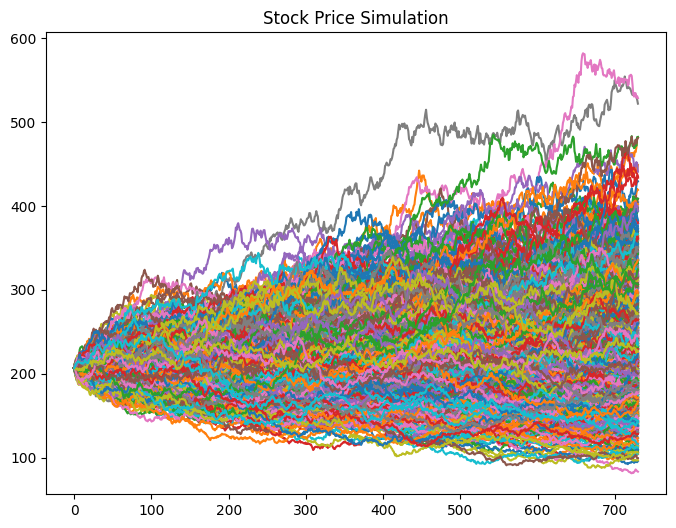

In [5]:
# visualize path
pricer_model.monte_carlo.option_pricer.visualize()